In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LinearRegression

from sklearn.tree import DecisionTreeRegressor

from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import joblib

In [2]:
df = pd.read_csv("../data/clean_sales.csv")

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Product Name,Sales,Quantity,Discount,Profit,Year,Month,Day,DayOfWeek,Quarter
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,2016,11,8,Tuesday,4
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,2016,11,8,Tuesday,4
2,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,2015,10,11,Sunday,4
3,6,CA-2014-115812,2014-06-09,2014-06-14,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,Eldon Expressions Wood and Plastic Desk Access...,48.8600,7,0.00,14.1694,2014,6,9,Monday,2
4,11,CA-2014-115812,2014-06-09,2014-06-14,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,Chromcraft Rectangular Conference Tables,1706.1840,9,0.20,85.3092,2014,6,9,Monday,2


In [3]:
print(df.shape)

df.info()

df.head()

(2121, 26)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2121 entries, 0 to 2120
Data columns (total 26 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         2121 non-null   int64  
 1   Order ID       2121 non-null   object 
 2   Order Date     2121 non-null   object 
 3   Ship Date      2121 non-null   object 
 4   Ship Mode      2121 non-null   object 
 5   Customer ID    2121 non-null   object 
 6   Customer Name  2121 non-null   object 
 7   Segment        2121 non-null   object 
 8   Country        2121 non-null   object 
 9   City           2121 non-null   object 
 10  State          2121 non-null   object 
 11  Postal Code    2121 non-null   int64  
 12  Region         2121 non-null   object 
 13  Product ID     2121 non-null   object 
 14  Category       2121 non-null   object 
 15  Sub-Category   2121 non-null   object 
 16  Product Name   2121 non-null   object 
 17  Sales          2121 non-null   float64
 1

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Product Name,Sales,Quantity,Discount,Profit,Year,Month,Day,DayOfWeek,Quarter
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,2016,11,8,Tuesday,4
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,2016,11,8,Tuesday,4
2,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,2015,10,11,Sunday,4
3,6,CA-2014-115812,2014-06-09,2014-06-14,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,Eldon Expressions Wood and Plastic Desk Access...,48.8600,7,0.00,14.1694,2014,6,9,Monday,2
4,11,CA-2014-115812,2014-06-09,2014-06-14,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,Chromcraft Rectangular Conference Tables,1706.1840,9,0.20,85.3092,2014,6,9,Monday,2


In [5]:
categorical_columns = [
    "Order ID",
    "Ship Mode",
    "Customer ID",
    "Customer Name",
    "Segment",
    "Country",
    "City",
    "State",
    "Region",
    "Product ID",
    "Category",
    "Sub-Category",
    "Product Name",
    "DayOfWeek"
]

encoder = LabelEncoder()

for col in categorical_columns:
    df[col] = encoder.fit_transform(df[col])

In [6]:
df["Order Date"] = pd.to_datetime(df["Order Date"])

df["Ship Date"] = pd.to_datetime(df["Ship Date"])

df["Order Date"] = df["Order Date"].map(pd.Timestamp.toordinal)

df["Ship Date"] = df["Ship Date"].map(pd.Timestamp.toordinal)

In [23]:
# Target variable
y = df["Sales"]

# Remove Sales (target) and Profit (to avoid data leakage)
X = df.drop(["Sales", "Profit"], axis=1)

print("Feature Matrix Shape:", X.shape)
print("Target Shape:", y.shape)

Feature Matrix Shape: (2121, 24)
Target Shape: (2121,)


In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print(X_train.shape)

print(X_test.shape)

(1696, 24)
(425, 24)


In [38]:
lr = LinearRegression()

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

In [27]:
dt = DecisionTreeRegressor(random_state=42)

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

In [28]:
rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

In [29]:
def evaluate(y_true, pred):

    mae = mean_absolute_error(y_true, pred)

    mse = mean_squared_error(y_true, pred)

    rmse = np.sqrt(mse)

    r2 = r2_score(y_true, pred)

    return mae, rmse, r2

In [39]:
models = {
    "Linear Regression": lr_pred,
    "Decision Tree": dt_pred,
    "Random Forest": rf_pred
}

for model, prediction in models.items():

    mae, rmse, r2 = evaluate(y_test, prediction)

    print("="*40)

    print(model)

    print("MAE :", mae)

    print("RMSE :", rmse)

    print("R2 :", r2)

Linear Regression
MAE : 304.5953688543149
RMSE : 506.6554856500197
R2 : 0.16226212160959175
Decision Tree
MAE : 242.17217835294116
RMSE : 517.4115712803433
R2 : 0.12631490233816078
Random Forest
MAE : 199.03300732235294
RMSE : 404.92898477229073
R2 : 0.4648933065708386


In [31]:
best_model = rf

In [32]:
import joblib

joblib.dump(best_model, "../models/sales_model.pkl")
print("Model saved successfully!")

joblib.dump(list(X.columns), "../models/feature_columns.pkl")
print("Feature columns saved successfully!")

Model saved successfully!
Feature columns saved successfully!


<Axes: title={'center': 'Feature Importance'}>

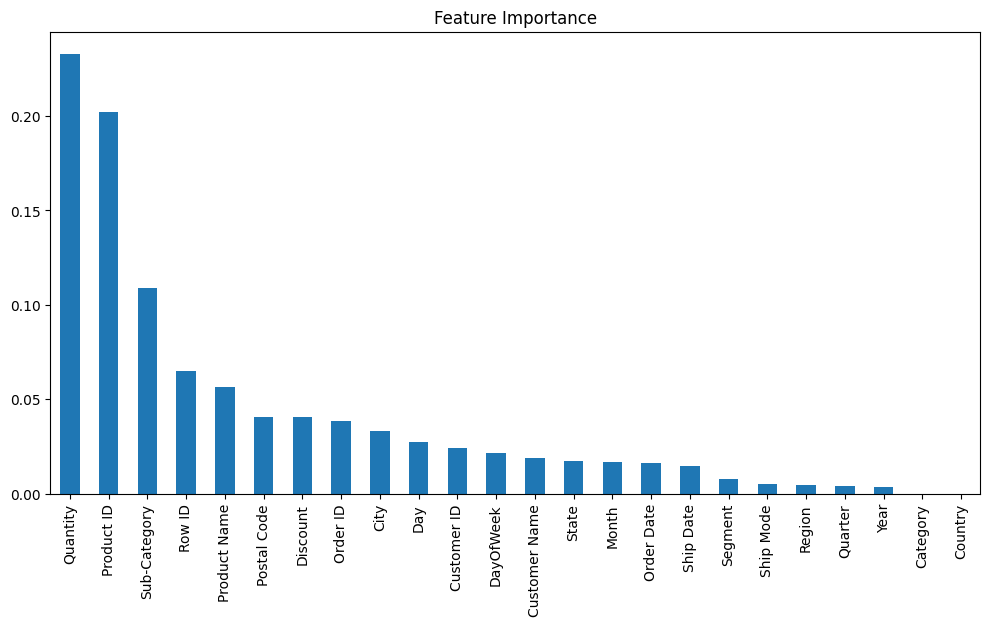

In [33]:
importance = pd.Series(
    rf.feature_importances_,
    index=X.columns
)

importance = importance.sort_values(ascending=False)

importance.plot(
    kind="bar",
    figsize=(12,6),
    title="Feature Importance"
)

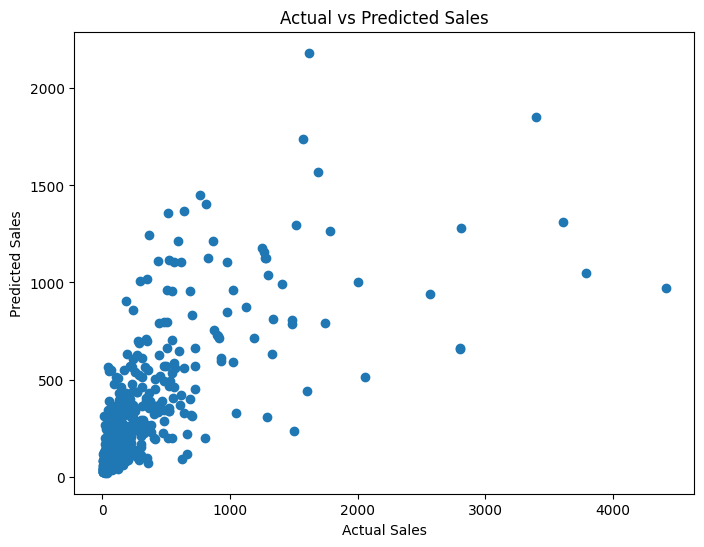

In [34]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(y_test, rf_pred)

plt.xlabel("Actual Sales")

plt.ylabel("Predicted Sales")

plt.title("Actual vs Predicted Sales")

plt.show()

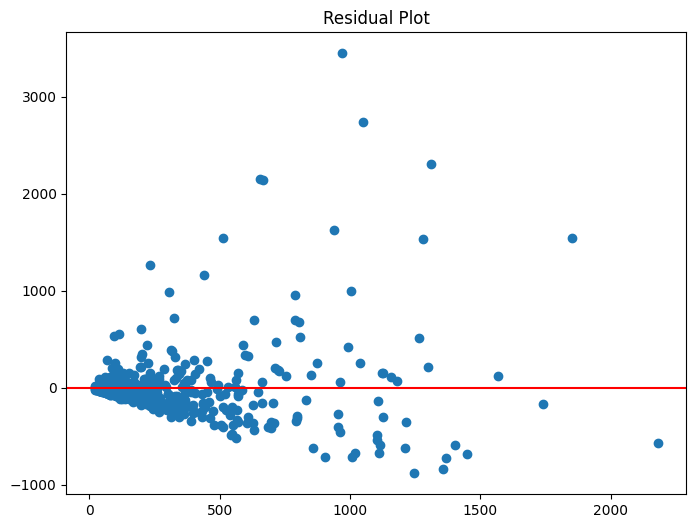

In [35]:
residual = y_test - rf_pred

plt.figure(figsize=(8,6))

plt.scatter(rf_pred, residual)

plt.axhline(
    y=0,
    color="red"
)

plt.title("Residual Plot")

plt.show()

In [36]:
sample = X.iloc[[0]]

prediction = rf.predict(sample)

print("Predicted Sales :", prediction[0])

Predicted Sales : 267.44137599999954


In [37]:
print(X.columns.tolist())

['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Quantity', 'Discount', 'Year', 'Month', 'Day', 'DayOfWeek', 'Quarter']
